In [1]:
import h5py
import matplotlib.pyplot as plt
import os
import numpy as np
import tidy3d as td
import sys
import scipy
# Assuming /AutomationModule is in the root directory of your project
sys.path.append(os.path.abspath(rf'../../../../../tidy3d'))

from AutomationModule import * 

import AutomationModule as AM

plt.rc('font', family='Arial')

In [2]:
files = {
    "no_absorbers": "./data/L_1_12x/field_data_12x_raw_field_Ex_Ey_Ez_L_1_ff_0p2237_n_2p90.h5",
    "absorbers": "./data/L_1_12x/field_data_12x_raw_field_Ex_Ey_Ez_L_1_ff_0p2237_n_2p90_absorbers.h5",
}

# Header info via h5py (no need to load ~24 GB of fields just to print this).
# T = 1/df is the unaliased time span of the synthetic-pulse reconstruction.
for tag, fname in files.items():
    with h5py.File(fname, "r") as h5f:
        fr = np.asarray(h5f["2.90"]["f"])
    dfr = np.mean(np.diff(fr))
    print(f"{tag}: Nf={len(fr)}, f=[{fr[0]/1e12:.3f},{fr[-1]/1e12:.3f}] THz, "
          f"df={dfr/1e9:.3f} GHz, T=1/df={1/dfr*1e12:.2f} ps")

# Explicit choice of the analyzed dataset (the old loop silently kept whichever
# file happened to be loaded last).
data = AM.read_hdf5_as_dict(files["absorbers"])

no_absorbers: Nf=1700, f=[37.474,119.917] THz, df=48.524 GHz, T=1/df=20.61 ps
absorbers: Nf=1700, f=[37.436,146.233] THz, df=64.036 GHz, T=1/df=15.62 ps


In [3]:
data.keys()

dict_keys(['2.90'])

In [4]:
gap_data = AM.read_hdf5_as_dict(rf"../../20250630 MPB Bands analysis/Data/gap_data.hdf5")
gaps_ff_22_n_2p90=14.3/(gap_data["Circular"]["0.22"]["gap_edges"][np.where(gap_data["Circular"]["0.22"]["n"]==2.9)[0]]).flatten()

In [5]:
a=2.562629142772549
gap_center = a/(np.sum(gaps_ff_22_n_2p90)/2)

a/gaps_ff_22_n_2p90

array([0.43214708, 0.46009945])

In [6]:

def diameter(intensity_array,x,y):
    """Participation-ratio diameter of a 2D intensity profile."""
    intensity = intensity_array
    integral_1 = scipy.integrate.simpson(scipy.integrate.simpson(intensity**2, x=y, axis=1), x=x, axis=0)
    integral_2 = scipy.integrate.simpson(scipy.integrate.simpson(intensity, x=y, axis=1), x=x, axis=0)**2
    
    return 2*np.sqrt((integral_2/integral_1)/np.pi)


def radial_sigma2(intensity_array, x, y, center=(0.0, 0.0)):
    """Cherroret observable: <rho^2> of a 2D transmitted intensity profile.

    ``center=(x0, y0)`` measures rho from that point; the default (0, 0) is the
    incident beam axis, matching the definition just before Eq. (3) of
    Cherroret, Skipetrov & van Tiggelen, PRE 82, 056603 (2010).
    ``center="centroid"`` subtracts the intensity centroid instead
    (single-realization robustness check).
    """
    intensity = np.asarray(intensity_array, dtype=float)
    X = np.asarray(x, dtype=float)[:, None]
    Y = np.asarray(y, dtype=float)[None, :]

    norm = scipy.integrate.simpson(scipy.integrate.simpson(intensity, x=y, axis=1), x=x, axis=0)
    if not np.isfinite(norm) or norm <= 0:
        return np.nan

    if center == "centroid":
        x0 = scipy.integrate.simpson(scipy.integrate.simpson(X * intensity, x=y, axis=1), x=x, axis=0) / norm
        y0 = scipy.integrate.simpson(scipy.integrate.simpson(Y * intensity, x=y, axis=1), x=x, axis=0) / norm
    else:
        x0, y0 = center

    rho2 = (X - x0) ** 2 + (Y - y0) ** 2
    return scipy.integrate.simpson(scipy.integrate.simpson(rho2 * intensity, x=y, axis=1), x=x, axis=0) / norm


In [7]:

from scipy.fft import fft  # forward FFT inverts Tidy3D's exp(+2*pi*i*f*t) DFT convention (e^{-i w t} fields)
from scipy.signal.windows import gaussian, tukey


def diameter_time_domain(field, a, nu_center=None, delta_nu=0.01,
                         background_rho=25.0, frame_floor=0.0,
                         power_floor_fraction=1e-4,
                         chunk=64, window="tukey", oversample=1,
                         diameter_type="participation_ratio",
                         sigma_center=(0.0, 0.0), return_diagnostics=False):
    """Reconstruct time-domain beam widths from the complex frequency-domain field.

    Synthesizes a pulse of bandwidth ``delta_nu`` centred at ``nu_center`` and
    returns per-delay widths of I(x,y,t) = sum_i |E_i(x,y,t)|^2. With Tidy3D's
    source-normalized data, t = 0 is the arrival of the incident pulse peak.
    The reconstruction is periodic with T = 1/df; samples beyond the power
    minimum separating the pulse from its periodic copy (wrap-around) are
    marked untrusted and ``t_valid_max`` is reported in the diagnostics.

    The primary Cherroret observable is ``diagnostics["sigma2_origin_t"]``
    = <rho^2>(t)/a^2 from the beam axis. <rho^2> is extremely sensitive to
    weak background spread over the monitor (a uniform background alone gives
    <rho^2>/a^2 ~ 750 for this aperture), so the mean intensity in the annulus
    rho > background_rho*a is subtracted from each frame; the residual is kept
    unclipped so it averages to zero in the moments (``background_rho=None``
    disables this). ``frame_floor`` optionally zeroes pixels below that
    fraction of the frame maximum -- report sigma^2 for a couple of values to
    bracket the tail-truncation systematic; it biases sigma^2 low.

    Keep ``delta_nu`` <= 0.02 when probing the band gap (gap width 0.028);
    off-gap prefer ~0.04-0.05 so the pulse duration ~1/(Nwin*df) stays below
    the Thouless time. ``window="gauss"`` has the lowest sidelobes and is
    preferable when chasing several decades of late-time decay.
    """
    x, y = np.asarray(field["x"]), np.asarray(field["y"])
    f = np.asarray(field["f"])
    nu = a * f / td.C_0
    df = np.mean(np.diff(f))

    if nu_center is None:
        nu_center = nu.min() + delta_nu / 2

    idx = np.where((nu >= nu_center - delta_nu / 2) &
                   (nu <= nu_center + delta_nu / 2))[0]
    Nwin = idx.size
    if Nwin < 2:
        raise ValueError(f"frequency window has only {Nwin} samples; increase delta_nu or move nu_center")

    print(f"Window: nu_center={nu_center:.3f}, delta_nu={delta_nu}, Nwin={Nwin}")

    if window == "box":
        w = np.ones(Nwin)
    elif window == "hann":
        w = np.hanning(Nwin)
    elif window == "tukey":
        w = tukey(Nwin, alpha=0.5)
    elif window == "gauss":
        w = gaussian(Nwin, std=Nwin / 6)
    else:
        raise ValueError(window)
    w = w.astype(np.float32)  # fields are complex64; a real window keeps them complex64

    # Zero-padding sinc-interpolates the time samples. It does not improve the
    # physical resolution, which is set by the selected bandwidth, ~1/(Nwin*df).
    Nfft = int(oversample) * Nwin
    dt = 1.0 / (Nfft * df)
    t = np.arange(Nfft) * dt
    physical_dt = 1.0 / (Nwin * df)
    print(f"Time axis: dt_interp={dt*1e15:.2f} fs, dt_physical~{physical_dt*1e12:.3f} ps, "
          f"T={1/df*1e12:.2f} ps, Nfft={Nfft} (oversample x{int(oversample)})")

    nx, ny = x.size, y.size
    intensity_t = np.zeros((nx, ny, Nfft), dtype=np.float32)
    for comp in ("Ex", "Ey", "Ez"):
        comp_arr = field[comp]
        for i0 in range(0, nx, chunk):
            i1 = min(i0 + chunk, nx)
            E_w = np.asarray(comp_arr[i0:i1, :, 0, idx])
            E_w *= w
            E_t = fft(E_w, n=Nfft, axis=-1)
            intensity_t[i0:i1] += (E_t.real ** 2 + E_t.imag ** 2).astype(np.float32)
            del E_w, E_t

    P_t = intensity_t.sum(axis=(0, 1), dtype=np.float64)
    P_peak = P_t.max()
    m_peak = int(np.argmax(P_t))
    t_d = t[m_peak]
    # watershed between the pulse and its periodic (wrap-around) copy
    m_cut = m_peak + int(np.argmin(P_t[m_peak:]))

    bg_mask = None
    if background_rho is not None:
        X = np.asarray(x, dtype=float)[:, None]
        Y = np.asarray(y, dtype=float)[None, :]
        bg_mask = (X ** 2 + Y ** 2) >= (background_rho * a) ** 2
        if not bg_mask.any():
            raise ValueError(f"background_rho={background_rho} a lies outside the monitor")

    d_t = np.full(Nfft, np.nan)
    sigma2_origin_t = np.full(Nfft, np.nan)
    background_t = np.full(Nfft, np.nan)
    trusted_power = P_t > power_floor_fraction * P_peak
    trusted_power[m_cut + 1:] = False

    for m in range(Nfft):
        if not trusted_power[m]:
            continue
        I = intensity_t[..., m].astype(np.float64)
        if bg_mask is not None:
            bg = I[bg_mask].mean()
            background_t[m] = bg
            I -= bg
        if frame_floor > 0:
            I[I <= frame_floor * I.max()] = 0.0
        sigma2_origin_t[m] = radial_sigma2(I, x, y, center=sigma_center)

        if diameter_type == "participation_ratio":
            d_t[m] = diameter(I, x, y)
        elif diameter_type == "second_moment_origin":
            d_t[m] = 2 * np.sqrt(sigma2_origin_t[m])
        else:
            raise ValueError(f"Unknown diameter_type: {diameter_type}")

    diagnostics = {
        "sigma2_origin_t": sigma2_origin_t / a**2,
        "P_t": P_t,
        "P_norm": P_t / P_peak,
        "trusted_power": trusted_power,
        "background_t": background_t,
        "m_peak": m_peak,
        "t_valid_max": t[m_cut],
        "idx": idx,
        "nu_window": nu[idx],
        "df": df,
        "physical_dt": physical_dt,
        "time_span": 1.0 / df,
        "window_weights": w,
    }

    if return_diagnostics:
        return t, d_t / a, nu_center, t_d, diagnostics
    return t, d_t / a, nu_center, t_d


Window: nu_center=0.390, delta_nu=0.02, Nwin=37
Time axis: dt_interp=84.41 fs, dt_physical~0.422 ps, T=15.62 ps, Nfft=185 (oversample x5)
Window: nu_center=0.410, delta_nu=0.02, Nwin=36
Time axis: dt_interp=72.30 fs, dt_physical~0.434 ps, T=15.62 ps, Nfft=216 (oversample x6)
Window: nu_center=0.446, delta_nu=0.015, Nwin=28
Time axis: dt_interp=79.67 fs, dt_physical~0.558 ps, T=15.62 ps, Nfft=196 (oversample x7)
Window: nu_center=0.900, delta_nu=0.05, Nwin=92
Time axis: dt_interp=84.87 fs, dt_physical~0.170 ps, T=15.62 ps, Nfft=184 (oversample x2)


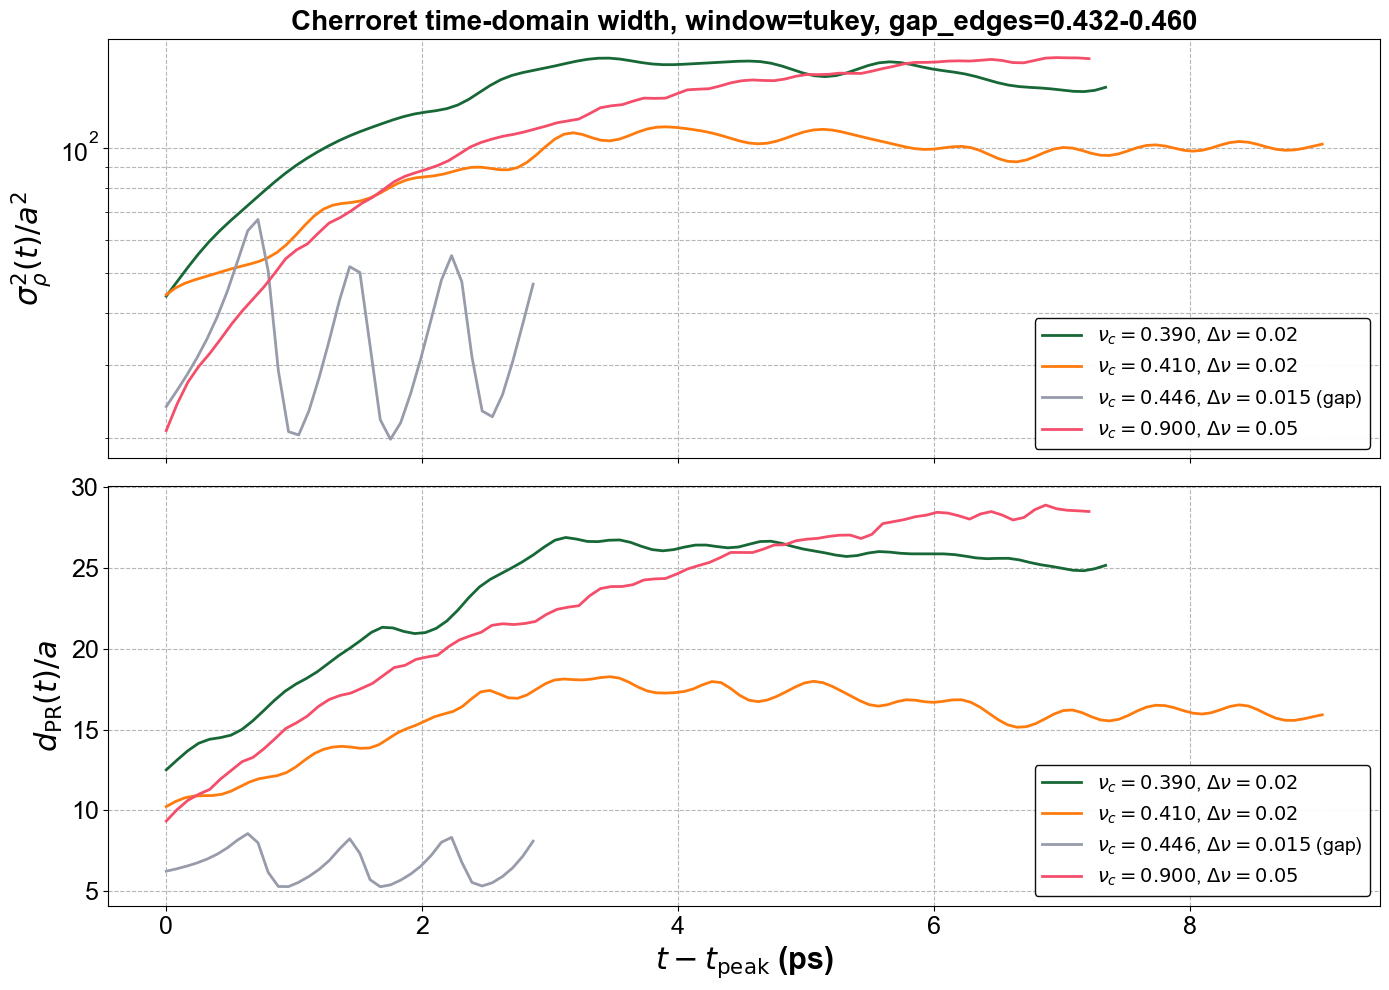

Cherroret FFT check summary (slope = 4D in a^2/ps; xi from sigma_inf^2 = 2 L xi (1 - xi/L))
nu_c    dnu    Nwin  dt_phys(ps)  t_peak(ps)  t_max(ps)  Nfit  slope(a^2/ps)  R2      late_s2/a^2  xi/a
0.390  0.020    37        0.422       0.591      11.82    88          11.07   0.525        148.4     nan
0.410  0.020    36        0.434       0.795      13.37   126          4.663   0.466        99.06     nan
0.446  0.015    28        0.558       0.159       7.97    37         -1.068   0.005        37.86     nan
0.900  0.050    92        0.170       0.594      12.99    86          20.05   0.936        160.8     nan


In [18]:

# --- Cherroret time-domain check from synthetic pulses -----------------------
# sigma_rho^2(t)/a^2 (primary observable, defined just before Eq. (3) of
# PRE 82, 056603) and the participation-ratio diameter (secondary robustness
# metric). Expected phenomenology: sigma^2 = 4 D t off-gap (diffusion);
# ~t^(1/2) growth then saturation at sigma_inf^2 ~ 2 L xi (1 - xi/L) near the
# gap (localization). The dashed line is the CW diffusive value (2/3)(L/a)^2
# from Eq. (4); the time-resolved diffusive curve crosses it near the Thouless
# time and gap curves should saturate below it.
fig, (ax_sig, ax_pr) = plt.subplots(2, 1, figsize=(14, 10), dpi=100, sharex=True)

L_slab = 14.3
window = "tukey"
TARGET_NFFT = 200
power_gate = 1e-4
fld = data["2.90"]
nu_full = a * np.asarray(fld["f"]) / td.C_0
# Per-window bandwidth: wide off-gap so the pulse (~1/(Nwin*df)) is shorter
# than the Thouless time; narrow in/near the gap (edges 0.432-0.460).
nu_windows = [(0.39, 0.02), (0.41, 0.02), (gap_center, 0.015), (0.90, 0.05)]
summary_rows = []

for nu_center, delta_nu in nu_windows:
    Nwin = int(np.sum((nu_full >= nu_center - delta_nu / 2) &
                      (nu_full <= nu_center + delta_nu / 2)))
    oversample = max(1, int(round(TARGET_NFFT / max(Nwin, 1))))
    t, d_pr, nu_c, t_d, diag = diameter_time_domain(
        fld, a, nu_center=nu_center, delta_nu=delta_nu, window=window,
        oversample=oversample, power_floor_fraction=power_gate,
        diameter_type="participation_ratio", return_diagnostics=True,
    )

    tau_ps = (t - t_d) * 1e12  # delay since pulse arrival
    sigma2 = diag["sigma2_origin_t"]
    valid = (tau_ps >= 0) & (t <= diag["t_valid_max"])  # stop at the wrap-around watershed
    label = rf"$\nu_c={nu_c:.3f}$, $\Delta\nu={delta_nu}$"
    if np.isclose(nu_c, gap_center):
        label += " (gap)"
    if np.isclose(nu_c, 0.35):
        label += " (aperture-limited)"

    ax_sig.plot(tau_ps[valid], sigma2[valid], lw=2, label=label)
    ax_pr.plot(tau_ps[valid], d_pr[valid], lw=2, label=label)

    # slope of sigma^2(tau) -> 4D; late-time level -> xi via 2*L*xi*(1-xi/L)
    fitmask = valid & np.isfinite(sigma2) & diag["trusted_power"]
    slope = r2 = late_sigma2 = xi_a = np.nan
    n_fit = int(np.sum(fitmask))
    if n_fit >= 4:
        xf, yf = tau_ps[fitmask], sigma2[fitmask]
        slope, intercept = np.polyfit(xf, yf, 1)  # units: a^2 / ps
        y_fit = slope * xf + intercept
        ss_tot = np.sum((yf - yf.mean()) ** 2)
        r2 = 1 - np.sum((yf - y_fit) ** 2) / ss_tot if ss_tot > 0 else np.nan
        late_sigma2 = np.nanmedian(yf[xf >= np.percentile(xf, 70)])
        L_a = L_slab / a
        disc = 1 - 2 * late_sigma2 / L_a**2
        xi_a = 0.5 * L_a * (1 - np.sqrt(disc)) if disc >= 0 else np.nan

    summary_rows.append((nu_c, delta_nu, Nwin, diag["physical_dt"] * 1e12, t_d * 1e12,
                         diag["t_valid_max"] * 1e12, n_fit, slope, r2, late_sigma2, xi_a))

# ax_sig.axhline((2 / 3) * (L_slab / a) ** 2, ls="--", color="k", lw=1.5,
#                label=r"CW diffusive $\frac{2}{3}(L/a)^2$, Eq. (4)")

ax_sig.set_yscale("log")
ax_sig.set_ylabel(r"$\sigma_\rho^2(t)/a^2$", fontsize=22, fontweight="bold")
ax_sig.grid(True, which="both", alpha=0.9, linestyle="--")
ax_sig.legend(loc="best", fontsize=14, framealpha=0.95, edgecolor="black")
ax_sig.set_title(
    rf"Cherroret time-domain width, window={window}, "
    rf"gap_edges={(a/gaps_ff_22_n_2p90)[0]:.3f}-{(a/gaps_ff_22_n_2p90)[1]:.3f}",
    fontsize=20, fontweight="bold",
)

ax_pr.set_xlabel(r"$t - t_{\rm peak}$ (ps)", fontsize=22, fontweight="bold")
ax_pr.set_ylabel(r"$d_{\rm PR}(t)/a$", fontsize=22, fontweight="bold")
ax_pr.grid(True, which="both", alpha=0.9, linestyle="--")
ax_pr.legend(loc="best", fontsize=14, framealpha=0.95, edgecolor="black")
for ax in (ax_sig, ax_pr):
    ax.tick_params(axis="both", which="major", labelsize=18)
    ax.set_facecolor("white")
fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()

print("Cherroret FFT check summary (slope = 4D in a^2/ps; xi from sigma_inf^2 = 2 L xi (1 - xi/L))")
print("nu_c    dnu    Nwin  dt_phys(ps)  t_peak(ps)  t_max(ps)  Nfit  slope(a^2/ps)  R2      late_s2/a^2  xi/a")
for row in summary_rows:
    print(f"{row[0]:5.3f}  {row[1]:5.3f}  {row[2]:4d}  {row[3]:11.3f}  {row[4]:10.3f}  {row[5]:9.2f}  {row[6]:4d}  "
          f"{row[7]:13.4g}  {row[8]:6.3f}  {row[9]:11.4g}  {row[10]:6.3g}")
